## 📝 Instrucciones para construir el modelo de regresion lineal ##


**Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)**

Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

## Paso 1: Carga del conjunto de datos a tu modelo

In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre demographic_health_data.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv

In [9]:
df = pd.read_csv('../data/raw/demographic_health_data.csv', delimiter= ',')

## Paso 2: Realiza un EDA completo

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

In [7]:
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [12]:
df.isnull().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [ ]:
# Estadística descriptiva
df.describe()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
count,3140.000000,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,30401.640764,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,...,5827.242357,13.073503,12.088089,14.053726,9326.577707,3.446242,3.207516,3.710478,2466.234076,4.635350
std,15150.559265,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,...,15720.551934,2.724351,2.622948,2.824828,29754.601185,0.568059,0.527740,0.613069,7730.422067,1.510447
min,1001.000000,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,...,7.000000,6.100000,5.500000,6.700000,11.000000,1.800000,1.700000,1.900000,3.000000,1.000000
25%,18180.500000,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,...,815.000000,11.200000,10.300000,12.100000,1187.750000,3.100000,2.900000,3.300000,314.750000,3.000000
50%,29178.000000,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,...,1963.500000,12.800000,11.800000,13.800000,2743.000000,3.400000,3.200000,3.700000,718.000000,5.000000
75%,45081.500000,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,...,4727.000000,14.800000,13.700000,15.900000,6679.250000,3.800000,3.500000,4.100000,1776.250000,6.000000
max,56045.000000,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,...,434075.000000,25.600000,24.200000,27.000000,952335.000000,6.200000,5.800000,6.600000,237766.000000,6.000000


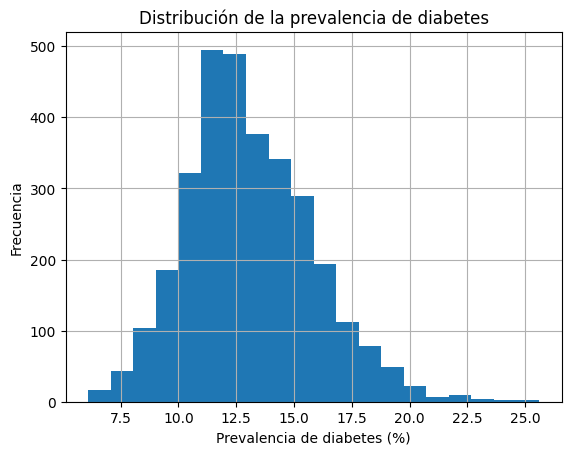

In [36]:
df['diabetes_prevalence'].hist(bins=20)
plt.title('Distribución de la prevalencia de diabetes')
ylabel = 'Frecuencia'
plt.ylabel(ylabel)
xlabel = 'Prevalencia de diabetes (%)'
plt.xlabel(xlabel)
plt.show()

In [37]:
df_num = df.select_dtypes(include=['int64', 'float64'])
target = 'diabetes_prevalence'
corr_target = df_num.corr()[target].sort_values(ascending=False)
print(corr_target)

diabetes_prevalence                                             1.000000
diabetes_Upper 95% CI                                           0.998409
diabetes_Lower 95% CI                                           0.998069
CKD_Lower 95% CI                                                0.924630
CKD_prevalence                                                  0.918514
                                                                  ...   
Percent of adults with a bachelor's degree or higher 2014-18   -0.669985
CI90UBINC_2018                                                 -0.720364
CI90LBINC_2018                                                 -0.720820
Median_Household_Income_2018                                   -0.723316
MEDHHINC_2018                                                  -0.723316
Name: diabetes_prevalence, Length: 106, dtype: float64


**Con tantas variables buscamos las de mayor y menor correlación**

In [48]:
corr_target.head(10)

diabetes_prevalence           1.000000
diabetes_Upper 95% CI         0.998409
diabetes_Lower 95% CI         0.998069
CKD_Lower 95% CI              0.924630
CKD_prevalence                0.918514
CKD_Upper 95% CI              0.906711
anycondition_Lower 95% CI     0.856473
Heart disease_Lower 95% CI    0.855832
anycondition_prevalence       0.850219
anycondition_Upper 95% CI     0.842287
Name: diabetes_prevalence, dtype: float64

In [49]:
corr_target.tail(10)

R_NATURAL_INC_2018                                                              -0.377873
Active Primary Care Physicians per 100000 Population 2018 (AAMC)                -0.387692
Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)   -0.401913
% White-alone                                                                   -0.410392
Med_HH_Income_Percent_of_State_Total_2018                                       -0.561531
Percent of adults with a bachelor's degree or higher 2014-18                    -0.669985
CI90UBINC_2018                                                                  -0.720364
CI90LBINC_2018                                                                  -0.720820
Median_Household_Income_2018                                                    -0.723316
MEDHHINC_2018                                                                   -0.723316
Name: diabetes_prevalence, dtype: float64

**Limpiamos variables que son derivadas de nuestro objetivo como:**

-diabetes_Upper 95% CI         0.998409

-diabetes_Lower 95% CI         0.998069

**Variables de identificación:**

'fips', 'STATE_FIPS', 'CNTY_FIPS', etc...

**Datos duplicados de población:**

'POP_ESTIMATE', 'Total_Population'

**Variables redundantes:**

'Civilian_labor_force_2018', 'Employed_2018', 'Unemployed_2018'

In [61]:
cols_to_drop = [ 
    col for col in df.columns
    if 'CI' in col or 'diabetes' in col and col != 'diabetes_prevalence'
]

cols_to_drop += [
    'fips', 'STATE_FIPS', 'CNTY_FIPS', 'COUNTY_NAME', 'STATE_NAME',
    'POP_ESTIMATE_2018', 'Total Population',
    'MEDHHINC_2018',
    'Civilian_labor_force_2018', 'Employed_2018', 'Unemployed_2018'
]

# eliminar variables absolutas de edad
cols_to_drop = [col for col in df.columns if 'y/o %' not in col and any(age in col for age in ['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80+'])]

# eliminar poblaciones absolutas de raza
cols_to_drop += [col for col in df.columns if 'pop' in col.lower() and '%' not in col]

# eliminar *_number
cols_to_drop += [col for col in df.columns if 'number' in col]

model = df.drop(columns=cols_to_drop)
model.shape
model.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 75 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   fips                                                                     3140 non-null   int64  
 1   0-9 y/o % of total pop                                                   3140 non-null   float64
 2   19-Oct                                                                   3140 non-null   int64  
 3   10-19 y/o % of total pop                                                 3140 non-null   float64
 4   20-29 y/o % of total pop                                                 3140 non-null   float64
 5   30-39 y/o % of total pop                                                 3140 non-null   float64
 6   40-49 y/o % of total pop                                                 3140 non-n

## Paso 3: Construye un modelo de regresión
Comienza a resolver el problema implementando un modelo de regresión lineal y analiza los resultados. A continuación, utilizando los mismos datos y los atributos por defecto, construye un modelo Lasso y compara los resultados con la regresión lineal base.

Analiza cómo evoluciona el R2 cuando el hiperparámetro del modelo Lasso cambia (puedes por ejemplo empezar a probar desde el valor 0.0 e ir aumentándolo hasta un valor de 20). Dibuja estos valores en un diagrama de líneas.

## Paso 4: Optimiza el modelo de regresión anterior
Después de entrenar el modelo Lasso, si los resultados no son satisfactorios, optimízalo empleando alguna de las técnicas vistas anteriormente.